In [1]:
# Firedrake coupled Saarelma–Connor solver tests
#
# Run from `tests/` (so `ROOT` points at the repo). Requires Firedrake +
# parent-class deps (OpenFUSIONToolkit, eqdsk/p-file inputs).

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

INPUT_DIR = ROOT / "src" / "inputs" / "PT_Hmode"
MHD_FP = INPUT_DIR / "g150840.03000"
KPROF_FP = INPUT_DIR / "p150840.03000"

# `solver-firedrake.py` has a hyphen — load by file path.
_fd_spec = importlib.util.spec_from_file_location(
    "solver_firedrake",
    ROOT / "src" / "solver-firedrake.py",
)
_fd_mod = importlib.util.module_from_spec(_fd_spec)
_fd_spec.loader.exec_module(_fd_mod)
saarelma_connor_firedrake = _fd_mod.saarelma_connor_firedrake


/Users/nelsonlab/codes/saarelma-conner-ped/src/solver.py:1112: SyntaxWarning: invalid escape sequence '\e'
  Saarelma \emph{et al.}~2023): exponential attenuation of FC neutrals
firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:

# Shared solve kwargs (override per cell as needed).
SOLVE_KW = dict(
    x_res=200,
    mesh_n=400,
    fe_degree=2,
    use_picard=True,
    picard_tol=1e-4,
    max_picard=40,
    relax=0.5,
    ne_inner_bc="neumann",   # Saarelma A7 default; see dirichlet comparison below
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    verbose=True,
)


In [3]:
model = saarelma_connor_firedrake(
    P_tot_e=5e6,
    alpha_crit=1.0,
    C_KBM=0.1,
    De_chie_etg=0.5,
    nFC_x0=1e15,          # m^-3 at separatrix
    mhd_fp=str(MHD_FP),
    kprof_fp=str(KPROF_FP),
    # nFC_threshold=0.01, nCX_threshold=0.01,  # adaptive x_inner (default)
    # psi_N_inner_boundary=0.97,               # fixed inner boundary instead
)

# # Pre-solve grid setup (no Firedrake yet): locates x_inner from neutral thresholds.
# model.form_factor(type="FC")
# model.form_factor(type="cx")
# model.setup_solver_grids(res=SOLVE_KW["x_res"])
# model.find_inner_boundary()

# print(f"psi_N inner = {model.psi_N_inner_boundary:.4f}")
# print(f"x_inner     = {model.x_inner:.4e} m")
# print(f"ne_x0       = {model.ne_x0:.3e} m^-3")
# print(f"nFC_x0      = {model.nFC_x0:.3e} m^-3")
# print(f"nCX_x0      = {model.nCX_x0:.3e} m^-3")

psi_N_inner_boundary: 0.8945
x_inner: -0.0386 m
[firedrake] x_inner        = -3.8591e-02 m
[firedrake] ne_inner_bc    = 'neumann'
[firedrake] ne(x_inner)    = 4.964e+19 m^-3 (p-file)
[firedrake] dne/dx(x_in)   = -3.659e+19 m^-4 (p-file)
[firedrake] ne_x0          = 1.299e+19 m^-3
[firedrake] nFC_x0         = 1.000e+15 m^-3
[firedrake] nCX_x0         = 1.000e+14 m^-3


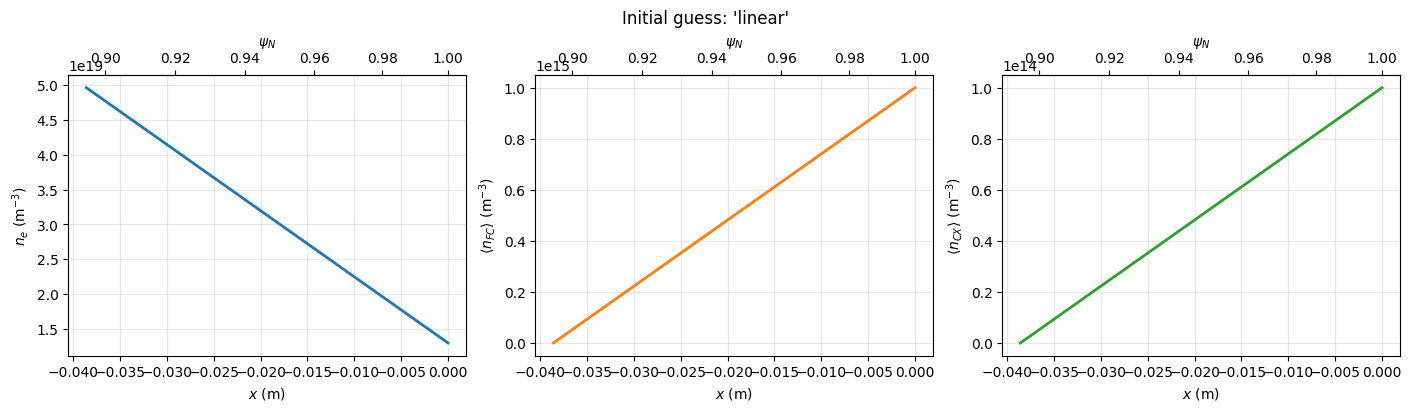

[firedrake] Picard iter   0:  ||dne||/||ne|| = 1.103e+00
[firedrake] Picard iter   1:  ||dne||/||ne|| = 1.031e+00
[firedrake] Picard iter   2:  ||dne||/||ne|| = 1.593e+00
[firedrake] Picard iter   3:  ||dne||/||ne|| = 1.671e+00
[firedrake] Picard iter   4:  ||dne||/||ne|| = 2.377e+00
[firedrake] Picard iter   5:  ||dne||/||ne|| = 1.943e+00
[firedrake] Picard iter   6:  ||dne||/||ne|| = 1.308e+00
[firedrake] Picard iter   7:  ||dne||/||ne|| = 8.045e-01
[firedrake] Picard iter   8:  ||dne||/||ne|| = 4.721e-01
[firedrake] Picard iter   9:  ||dne||/||ne|| = 2.698e-01
[firedrake] Picard iter  10:  ||dne||/||ne|| = 1.517e-01
[firedrake] Picard iter  11:  ||dne||/||ne|| = 8.444e-02
[firedrake] Picard iter  12:  ||dne||/||ne|| = 4.663e-02
[firedrake] Picard iter  13:  ||dne||/||ne|| = 2.560e-02
[firedrake] Picard iter  14:  ||dne||/||ne|| = 1.398e-02
[firedrake] Picard iter  15:  ||dne||/||ne|| = 7.600e-03
[firedrake] Picard iter  16:  ||dne||/||ne|| = 4.114e-03
[firedrake] Picard iter  17:  |

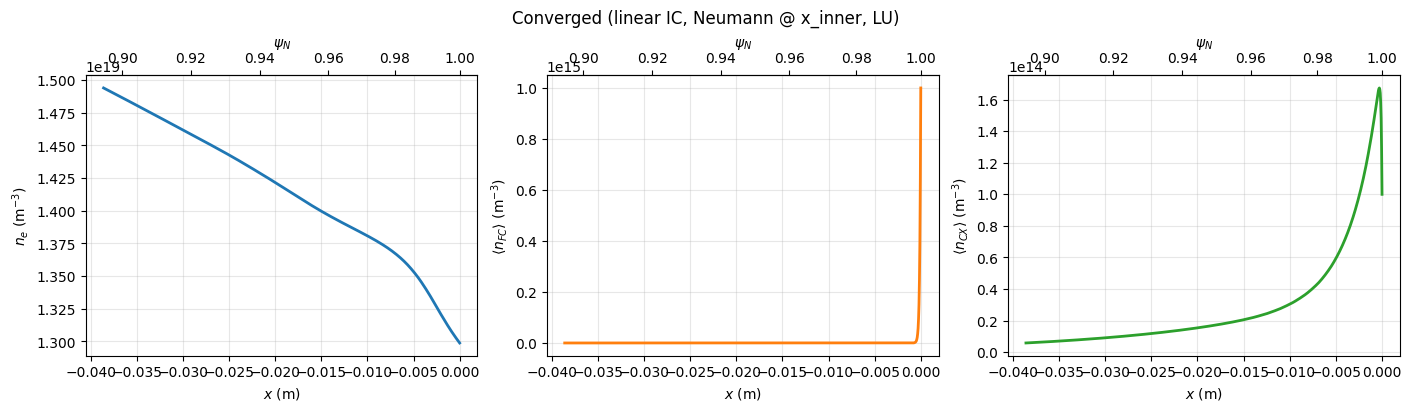

In [4]:
# --- Baseline: Neumann n_e at x_inner, linear initial guess, direct LU ---
x_sol, ne_sol, nFC_sol, nCX_sol = model.solve_firedrake(
  **SOLVE_KW,
  initial_guess="linear",
)

# Converged profiles (x bottom, psi_N top on each panel)
model._plot_profiles(
    x_sol, ne_sol, nFC_sol, nCX_sol,
    title="Converged (linear IC, Neumann @ x_inner, LU)",
)

In [ ]:
# --- Tanh pedestal initial guess (plots IC when verbose=True, then solution) ---
# Re-use the same model instance; solve_firedrake re-runs setup each call.
x_sol_tanh, ne_tanh, nFC_tanh, nCX_tanh = model.solve_firedrake(
    **SOLVE_KW,
    initial_guess="tanh",
    tanh_width=None,    # default 0.1 * |x_inner|
    tanh_center=None,   # default -tanh_width
)

model._plot_profiles(
    x_sol_tanh, ne_tanh, nFC_tanh, nCX_tanh,
    title="Converged (tanh IC, Neumann @ x_inner, LU)",
)

In [ ]:
# --- p-file-based initial guess (n_e from p-file, FC exponential from separatrix) ---
x_sol_pf, ne_pf, nFC_pf, nCX_pf = model.solve_firedrake(
    **SOLVE_KW,
    initial_guess="pfile",
)

model._plot_profiles(
    x_sol_pf, ne_pf, nFC_pf, nCX_pf,
    title="Converged (pfile IC, Neumann @ x_inner, LU)",
)

In [ ]:
# --- Compare Neumann vs Dirichlet n_e at x_inner (same linear IC) ---
results_bc = {}
for bc in ("neumann", "dirichlet"):
    kw = {**SOLVE_KW, "ne_inner_bc": bc, "initial_guess": "linear", "verbose": False}
    results_bc[bc] = model.solve_firedrake(**kw)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
fig.suptitle(r"$n_e$ inner BC: Neumann vs Dirichlet (linear IC)")

labels = {"neumann": "Neumann", "dirichlet": "Dirichlet"}
colors = {"neumann": "tab:blue", "dirichlet": "tab:orange"}
fields = [
    (lambda r: r[1] / 1e19, r"$n_e$ ($10^{19}$ m$^{-3}$)"),
    (lambda r: r[2] / 1e15, r"$\langle n_{FC}\rangle$ ($10^{15}$ m$^{-3}$)"),
    (lambda r: r[3] / 1e15, r"$\langle n_{CX}\rangle$ ($10^{15}$ m$^{-3}$)"),
]

for ax, (fn, ylab) in zip(axes, fields):
    for bc, (x, ne, nfc, ncx) in results_bc.items():
        ax.plot(x, fn((x, ne, nfc, ncx)), lw=2, color=colors[bc], label=labels[bc])
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_xlabel(r"$x$ (m)")
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.show()

In [ ]:
# --- Optional: GMRES + algebraic multigrid (GAMG) on each Newton Jacobian ---
# For this 1D problem LU is usually faster; use gamg when mesh_n / fe_degree is large.
x_sol_mg, ne_mg, nFC_mg, nCX_mg = model.solve_firedrake(
    **{**SOLVE_KW, "linear_solver": "gamg", "ksp_rtol": 1e-8, "ksp_max_it": 200},
    initial_guess="linear",
)

model._plot_profiles(
    x_sol_mg, ne_mg, nFC_mg, nCX_mg,
    title="Converged (linear IC, Neumann, GAMG)",
)

In [ ]:
# --- Optional: full Newton (no Picard outer loop) — less robust, good for debugging ---
# x_sol_newton, ne_n, nFC_n, nCX_n = model.solve_firedrake(
#     **{**SOLVE_KW, "use_picard": False},
#     initial_guess="pfile",
# )
# model._plot_profiles(x_sol_newton, ne_n, nFC_n, nCX_n, title="Full Newton, pfile IC")

In [7]:
# Scan solver configurations (model free parameters unchanged — only
# use_picard, ne_inner_bc, and initial_guess vary).
import time

model = saarelma_connor_firedrake(
    P_tot_e=5e6,
    alpha_crit=0.0075,
    C_KBM=1.78,
    De_chie_etg=7.5,
    nFC_x0=3.16e15,          # m^-3 at separatrix
    mhd_fp=str(MHD_FP),
    kprof_fp=str(KPROF_FP),
    psi_N_inner_boundary=0.8906,
    nFC_threshold=None, 
    nCX_threshold=None,
    # nFC_threshold=0.01, nCX_threshold=0.01,  # adaptive x_inner (default)
    # psi_N_inner_boundary=0.97,               # fixed inner boundary instead
)

scan_results = {}

SOLVE_KW = dict(
    x_res=200,
    mesh_n=400,
    fe_degree=2,
    picard_tol=1e-4,
    max_picard=40,
    relax=0.5,
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    verbose=False,
)

for use_picard in [True]:
    for ne_inner_bc in ["neumann", "dirichlet"]:
        for initial_guess in ["linear", "tanh", "pfile"]:
            key = (use_picard, ne_inner_bc, initial_guess)
            label = (
                f"Picard={use_picard}, "
                f"BC={ne_inner_bc}, IC={initial_guess}"
            )
            print(f"\n--- {label} ---")
            try:
                t0 = time.perf_counter()
                x_sol, ne_sol, nFC_sol, nCX_sol = model.solve_firedrake(
                    **SOLVE_KW,
                    use_picard=use_picard,
                    ne_inner_bc=ne_inner_bc,
                    initial_guess=initial_guess,
                )
                elapsed = time.perf_counter() - t0
                print(f"  solve_firedrake: {elapsed:.2f} s")
                scan_results[key] = dict(
                    ok=True,
                    x=x_sol,
                    ne=ne_sol,
                    nFC=nFC_sol,
                    nCX=nCX_sol,
                )
                print(
                    f"  OK  ne(sep)={float(ne_sol[np.argmin(np.abs(x_sol))]):.3e} m^-3"
                )
            except Exception as exc:
                scan_results[key] = dict(ok=False, error=str(exc))
                print(f"  FAILED: {exc}")

n_ok = sum(1 for r in scan_results.values() if r["ok"])
print(f"\nScan complete: {n_ok}/{len(scan_results)} configurations converged.")

try:
    t0_og = time.perf_counter()
    og_model_x, og_model_ne, og_model_dne_dx = model.solve(x_res=SOLVE_KW["x_res"])
    elapsed_og = time.perf_counter() - t0_og
    print(f"  model.solve (Saarelma-Connor): {elapsed_og:.2f} s")
    # All parent profiles on the same BVP grid (returned x can differ from nFC_sol
    # if an old solver build left nFC on x_prev).
    og_model_x_ref = np.asarray(model.x_sol, dtype=float)
    og_model_x = og_model_x_ref.copy()
    og_model_ne = np.asarray(model.ne_sol, dtype=float)
    og_model_nFC = np.interp(og_model_x, og_model_x_ref, np.asarray(model.nFC_sol))
    og_model_nCX = np.interp(og_model_x, og_model_x_ref, np.asarray(model.nCX_sol))
    print(
        f"  Parent solve grid: {len(og_model_x)} points "
        f"(n_e, nFC, nCX aligned)"
    )
except Exception as exc:
    print(f"  Original Model FAILED: {exc}")


--- Picard=True, BC=neumann, IC=linear ---
  solve_firedrake: 0.56 s
  OK  ne(sep)=1.299e+19 m^-3

--- Picard=True, BC=neumann, IC=tanh ---
  solve_firedrake: 0.29 s
  OK  ne(sep)=1.299e+19 m^-3

--- Picard=True, BC=neumann, IC=pfile ---
  solve_firedrake: 0.29 s
  OK  ne(sep)=1.299e+19 m^-3

--- Picard=True, BC=dirichlet, IC=linear ---
  solve_firedrake: 0.32 s
  OK  ne(sep)=1.299e+19 m^-3

--- Picard=True, BC=dirichlet, IC=tanh ---
  solve_firedrake: 0.26 s
  OK  ne(sep)=1.299e+19 m^-3

--- Picard=True, BC=dirichlet, IC=pfile ---
  solve_firedrake: 0.23 s
  OK  ne(sep)=1.299e+19 m^-3

Scan complete: 6/6 configurations converged.
  model.solve (Saarelma-Connor): 0.08 s
  Parent solve grid: 225 points (n_e, nFC, nCX aligned)


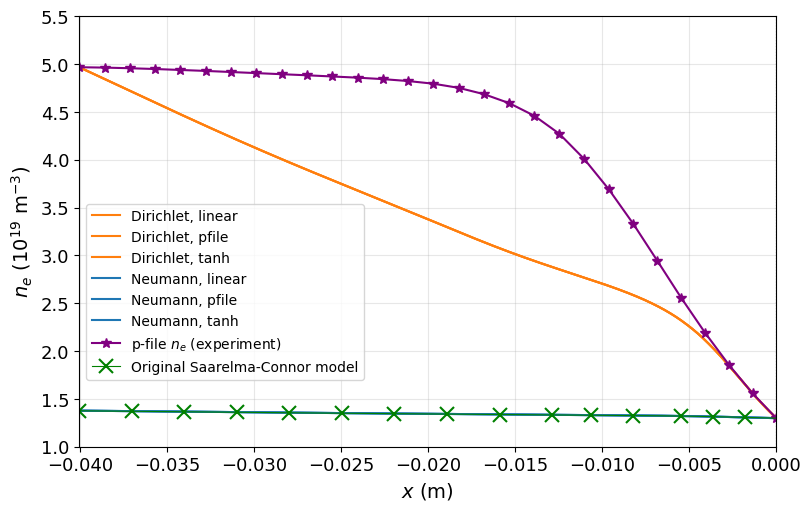

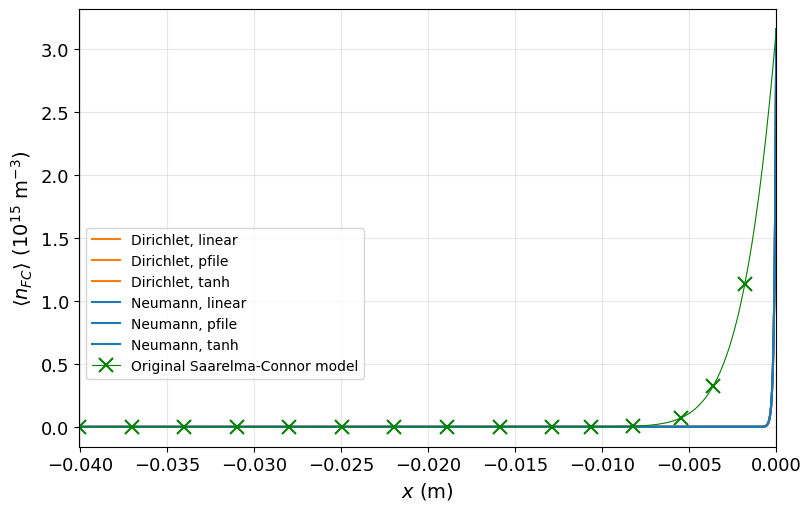

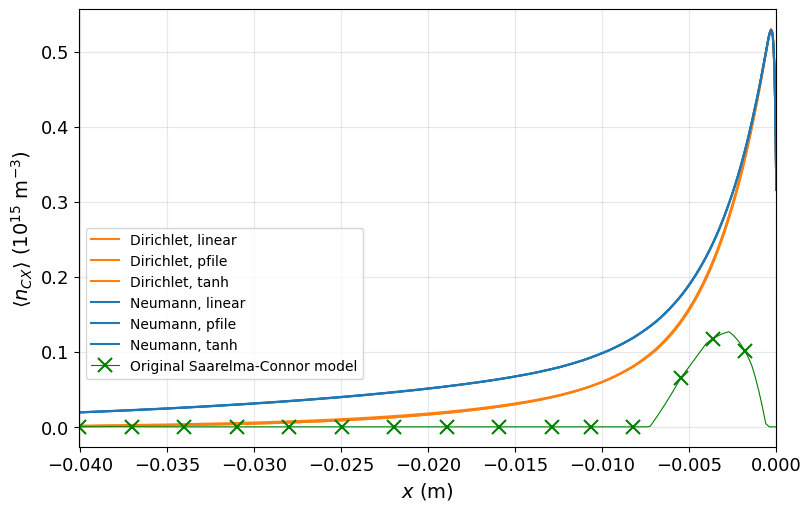

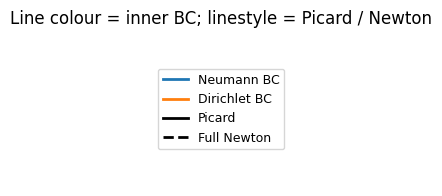

In [6]:
# Three separate overlay plots: n_e, n_FC, n_CX (all converged scan runs)
from matplotlib.lines import Line2D

linestyles = {True: "-", False: "--"}
colors_bc = {"neumann": "tab:blue", "dirichlet": "tab:orange"}


def _plot_og_saarelma_connor(ax, x_plot, y, scale, label="Original Saarelma-Connor model", x_y=None):
    """Sparse green markers for the parent ``solve()`` profile."""
    x_plot = np.asarray(x_plot, dtype=float)
    y = np.asarray(y, dtype=float)
    if x_y is None:
        x_y = x_plot
    else:
        x_y = np.asarray(x_y, dtype=float)
    if x_plot.shape != y.shape:
        y = np.interp(x_plot, x_y, y)
    markevery = max(1, len(x_plot) // 15)
    ax.plot(
        x_plot, y / scale,
        linestyle="-", color="green", marker="x",
        markevery=markevery, ms=10, mew=1.5, lw=0.8,
        label=label,
    )


def _overlay_scan_runs(ax, field, scale, ylabel, title):
    """Plot every successful scan configuration on one axes."""
    i=0
    for (use_picard, ne_inner_bc, initial_guess), res in sorted(scan_results.items()):
        if not res["ok"]:
            continue
        lbl = f"{ne_inner_bc.capitalize()}, {initial_guess}"
        ax.plot(
            res["x"],
            res[field] / scale,
            color=colors_bc[ne_inner_bc],
            ls=linestyles[use_picard],
            lw=1.5,
            label=lbl,
        )
        if i==0:
            ax.set_xlim(res["x"][0], res["x"][-1])
            i+=1

    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    # ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=13)
    ax.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))


# --- n_e ---
fig_ne, ax_ne = plt.subplots(figsize=(8, 5), constrained_layout=True)
_overlay_scan_runs(
    ax_ne, "ne", 1e19,
    r"$n_e$ ($10^{19}$ m$^{-3}$)",
    "Configuration scan — electron density",
)
ax_ne.plot(
    model.x_init, model.n_e_pres / 1e19, 
    "*-", color="purple", ms=7,
    label="p-file $n_e$ (experiment)",
)
try:
    _plot_og_saarelma_connor(ax_ne, og_model_x, og_model_ne, 1e19, x_y=og_model_x_ref)
except NameError:
    pass  # og_model_* not defined if parent solve failed
ax_ne.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))
ax_ne.set_ylim(1, 5.5)
plt.savefig("ne_scan.png", dpi=300)
plt.show()


# --- n_FC ---
fig_fc, ax_fc = plt.subplots(figsize=(8, 5), constrained_layout=True)
_overlay_scan_runs(
    ax_fc, "nFC", 1e15,
    r"$\langle n_{FC} \rangle$ ($10^{15}$ m$^{-3}$)",
    "Configuration scan — Franck-Condon neutrals",
)
try:
    _plot_og_saarelma_connor(ax_fc, og_model_x, og_model_nFC, 1e15, x_y=og_model_x_ref)
    ax_fc.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))
except NameError:
    pass
plt.savefig("nfc_scan.png", dpi=300)
plt.show()

# --- n_CX ---
fig_cx, ax_cx = plt.subplots(figsize=(8, 5), constrained_layout=True)
_overlay_scan_runs(
    ax_cx, "nCX", 1e15,
    r"$\langle n_{CX} \rangle$ ($10^{15}$ m$^{-3}$)",
    "Configuration scan — charge-exchange neutrals",
)
try:
    _plot_og_saarelma_connor(ax_cx, og_model_x, og_model_nCX, 1e15, x_y=og_model_x_ref)
    ax_cx.legend(fontsize=10, ncol=1, loc="lower left", bbox_to_anchor=(0, 0.14))
except NameError:
    pass
plt.savefig("ncx_scan.png", dpi=300)
plt.show()

# Legend key: colour = inner BC, linestyle = Picard vs full Newton
legend_elems = [
    Line2D([0], [0], color=colors_bc["neumann"], lw=2, label="Neumann BC"),
    Line2D([0], [0], color=colors_bc["dirichlet"], lw=2, label="Dirichlet BC"),
    Line2D([0], [0], color="k", ls="-", lw=2, label="Picard"),
    Line2D([0], [0], color="k", ls="--", lw=2, label="Full Newton"),
]
fig_key, ax_key = plt.subplots(figsize=(4, 2))
ax_key.legend(handles=legend_elems, loc="center", fontsize=9)
ax_key.axis("off")
ax_key.set_title("Line colour = inner BC; linestyle = Picard / Newton")

plt.show()

